# 🧪 Graphics Compiler Testing — NVIDIA SDET Role

**Focus:** Compiler verification, performance testing, regression detection  
**Languages:** Python, C/C++ concepts, HLSL/GLSL shader basics  
**Role:** Software Development Engineer in Test — Graphics Compiler Team

## What this role does
NVIDIA's graphics compiler takes shader code written by game developers (in HLSL or GLSL)
and compiles it into machine code that runs on the GPU. Your job is to make sure:

1. **Correctness** — compiled shaders produce the right output (pixels, values)
2. **Performance** — compiled code runs as fast as expected on GPU hardware
3. **Regressions** — new compiler changes don't break previously working shaders

| What you test | Why it's hard |
|---|---|
| Shader correctness | Floating point math, edge cases, undefined behavior |
| Compiler performance | Optimization passes can help or hurt |
| Regression detection | Thousands of shaders, subtle slowdowns |
| Cross-platform | Same shader must work on different GPU generations |

---

In this notebook you will:
1. Understand the **graphics pipeline** and what a shader compiler does
2. Learn **test planning** and how to structure test cases for a compiler
3. Build a **Python test framework** using real testing patterns
4. **Benchmark GPU kernels** and collect reliable performance data
5. Apply **statistical analysis** to detect performance regressions and outliers
6. Complete **3 challenges** that reflect real SDET work at NVIDIA

In [6]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import unittest
import time
import json
from dataclasses import dataclass, field
from typing import List, Dict, Optional

print("✅ Imports OK")
props = cp.cuda.runtime.getDeviceProperties(0)
print(f"   GPU: {props['name'].decode()}")

✅ Imports OK
   GPU: NVIDIA GeForce RTX 4070 SUPER


## 1. The Graphics Pipeline & Shader Compilers

When a game renders a frame, it runs a **graphics pipeline** on the GPU:

```
CPU sends draw call
        │
        ▼
  Vertex Shader      ← runs once per vertex (3D point)
  (HLSL/GLSL)           transforms 3D coordinates → 2D screen space
        │
        ▼
  Rasterization      ← GPU hardware fills in triangles
        │
        ▼
  Pixel/Fragment     ← runs once per pixel
  Shader                determines the final color of each pixel
  (HLSL/GLSL)           lighting, shadows, textures
        │
        ▼
  Output: pixels on screen
```

### What the compiler does
Shaders are written in high-level languages (HLSL for DirectX, GLSL for OpenGL/Vulkan).
The compiler translates them into GPU machine code:

```
HLSL Source Code
      │
      ▼  front-end parse
  Abstract Syntax Tree (AST)
      │
      ▼  optimization passes
  Intermediate Representation (IR)
      │  (dead code elimination, constant folding,
      │   loop unrolling, register allocation...)
      ▼  back-end code generation
  GPU Machine Code (SASS / PTX)
      │
      ▼
  Runs on GPU hardware
```

### Example: HLSL pixel shader
```hlsl
// Computes Phong lighting for one pixel
float4 PS_Main(float3 normal : NORMAL,
               float3 lightDir : TEXCOORD0) : SV_Target
{
    float  diffuse = max(dot(normalize(normal), normalize(lightDir)), 0.0);
    float3 color   = float3(1.0, 0.5, 0.2) * diffuse;
    return float4(color, 1.0);   // RGBA output
}
```

### What an SDET tests on this shader
| Test type | What to check |
|---|---|
| **Correctness** | Does `dot(n, l)` produce the right value? Does `max(..., 0)` clamp correctly? |
| **Edge cases** | `normal = (0,0,0)` → divide by zero in `normalize`? |
| **Performance** | Did a compiler change make this shader 10% slower? |
| **Regression** | Did fixing shader A break shader B? |

## 2. Test Planning

Before writing a single line of test code, an SDET writes a **test plan** — a document
describing *what* will be tested, *how*, and *what counts as passing*.

### Test categories for a compiler

| Category | Description | Example |
|---|---|---|
| **Functional** | Does the output match the spec? | `dot([1,0,0], [1,0,0])` should return `1.0` |
| **Edge case** | What happens at the boundaries? | `normalize([0,0,0])` — zero-length vector |
| **Regression** | Does new compiler break old shaders? | Run all 10,000 known-good shaders |
| **Performance** | Is the compiled code fast enough? | Shader X must run in < 0.5 ms |
| **Stress** | Does it handle extreme inputs? | 10,000 texture samples, deeply nested loops |
| **Compatibility** | Works across GPU generations? | Ada, Ampere, Turing, Volta |

### Test design principles

**Equivalence partitioning** — group inputs into classes that should behave the same:
```
For a clamp(x, min, max) function:
  Class 1: x < min   → expect min      e.g. clamp(-5, 0, 1) = 0
  Class 2: min ≤ x ≤ max → expect x   e.g. clamp(0.5, 0, 1) = 0.5
  Class 3: x > max   → expect max      e.g. clamp(5, 0, 1) = 1
  Edge:    x = min exactly             e.g. clamp(0, 0, 1) = 0
  Edge:    x = max exactly             e.g. clamp(1, 0, 1) = 1
```

**Boundary value analysis** — bugs cluster at edges, so test exactly at boundaries.

**Regression suite** — every bug that's ever been fixed becomes a test case,
so it can never silently reappear.

In [7]:
# ── Structured test plan as a Python dataclass ────────────────────────────────
# In a real team this would live in a document (Confluence) and be tracked in JIRA.
# Here we model it in code to make it executable.

@dataclass
class TestCase:
    id: str
    description: str
    category: str          # functional / edge / regression / performance
    inputs: dict
    expected: object
    tolerance: float = 0.0  # for float comparisons
    priority: str = 'P1'    # P0=blocker, P1=high, P2=medium, P3=low

@dataclass
class TestPlan:
    name: str
    component: str
    owner: str
    cases: List[TestCase] = field(default_factory=list)

    def summary(self):
        cats = {}
        for c in self.cases:
            cats[c.category] = cats.get(c.category, 0) + 1
        print(f"Test Plan : {self.name}")
        print(f"Component : {self.component}")
        print(f"Owner     : {self.owner}")
        print(f"Total     : {len(self.cases)} test cases")
        for cat, count in sorted(cats.items()):
            print(f"  {cat:15s}: {count}")

# Example: test plan for the dot() intrinsic in a shader compiler
dot_plan = TestPlan(
    name="dot() intrinsic — correctness & edge cases",
    component="HLSL front-end compiler",
    owner="sdet-graphics-team",
    cases=[
        TestCase("TC001", "dot product of unit vectors",
                 "functional", {"a": [1,0,0], "b": [1,0,0]}, 1.0, 1e-6),
        TestCase("TC002", "perpendicular vectors → 0",
                 "functional", {"a": [1,0,0], "b": [0,1,0]}, 0.0, 1e-6),
        TestCase("TC003", "anti-parallel vectors → -1",
                 "functional", {"a": [1,0,0], "b": [-1,0,0]}, -1.0, 1e-6),
        TestCase("TC004", "zero vector → 0",
                 "edge",       {"a": [0,0,0], "b": [1,0,0]}, 0.0, 1e-6),
        TestCase("TC005", "very large values — overflow check",
                 "edge",       {"a": [1e38,0,0], "b": [1e38,0,0]}, float('inf'), 0),
        TestCase("TC006", "NaN propagation",
                 "edge",       {"a": [float('nan'),0,0], "b": [1,0,0]}, float('nan'), 0),
        TestCase("TC007", "negative components",
                 "functional", {"a": [-1,-2,-3], "b": [4,5,6]}, -32.0, 1e-5),
        TestCase("TC008", "regression: issue #4521 — vec2 dot returned wrong sign",
                 "regression", {"a": [-1,1], "b": [1,-1]}, -2.0, 1e-6, "P0"),
    ]
)

dot_plan.summary()

Test Plan : dot() intrinsic — correctness & edge cases
Component : HLSL front-end compiler
Owner     : sdet-graphics-team
Total     : 8 test cases
  edge           : 3
  functional     : 4
  regression     : 1


## 3. Test Implementation & Automation

A test plan is useless if it isn't automated. NVIDIA uses internal test frameworks,
but the patterns are the same as standard Python testing.

### Key testing patterns

**Arrange → Act → Assert (AAA):**
```python
def test_dot_unit_vectors():
    # Arrange — set up inputs
    a = np.array([1.0, 0.0, 0.0])
    b = np.array([1.0, 0.0, 0.0])

    # Act — run the thing being tested
    result = shader_compiler.evaluate_dot(a, b)

    # Assert — check the output
    assert abs(result - 1.0) < 1e-6, f"Expected 1.0, got {result}"
```

**Parameterized tests** — run the same test logic with many inputs:
```python
@pytest.mark.parametrize("a,b,expected", [
    ([1,0,0], [1,0,0],  1.0),
    ([1,0,0], [0,1,0],  0.0),
    ([1,0,0], [-1,0,0], -1.0),
])
def test_dot(a, b, expected):
    assert abs(dot(a, b) - expected) < 1e-6
```

**Fixtures** — reusable setup/teardown:
```python
@pytest.fixture
def compiler():
    c = ShaderCompiler(target="ada_lovelace")
    c.initialize()
    yield c           # test runs here
    c.shutdown()      # teardown — always runs, even if test fails
```

In [8]:

# ── Mock shader compiler intrinsics (stand-in for a real compiler under test) ─
# In the real job, these would call into the actual NVIDIA compiler binary.

def shader_dot(a, b):
    """Mock implementation of HLSL dot() intrinsic."""
    a, b = np.array(a, dtype=np.float32), np.array(b, dtype=np.float32)
    with np.errstate(over='ignore'):
        return float(np.dot(a, b))

def shader_normalize(v):
    """Mock implementation of HLSL normalize() intrinsic."""
    v = np.array(v, dtype=np.float32)
    length = np.sqrt(np.dot(v, v))
    if length == 0:
        return v   # returns zero vector (matches HLSL spec)
    return v / length

def shader_clamp(x, lo, hi):
    """Mock implementation of HLSL clamp() intrinsic."""
    return float(np.clip(x, lo, hi))

def shader_lerp(a, b, t):
    """Mock implementation of HLSL lerp(a, b, t) = a + t*(b-a)."""
    return float(a + t * (b - a))


# ── Test runner that executes a TestPlan against a compiler function ───────────

def run_test_plan(plan: TestPlan, compiler_fn, verbose=True):
    """Execute all test cases in a plan and report results."""
    passed = failed = errors = 0
    failures = []

    for tc in plan.cases:
        try:
            result = compiler_fn(**tc.inputs)

            # Handle NaN expected
            if isinstance(tc.expected, float) and np.isnan(tc.expected):
                ok = np.isnan(result)
            elif isinstance(tc.expected, float) and np.isinf(tc.expected):
                ok = np.isinf(result)
            else:
                ok = abs(result - tc.expected) <= tc.tolerance

            if ok:
                passed += 1
                if verbose: print(f"  ✅ [{tc.id}] {tc.description}")
            else:
                failed += 1
                msg = f"expected {tc.expected}, got {result:.6f}"
                failures.append((tc.id, msg))
                if verbose: print(f"  ❌ [{tc.id}] {tc.description}  →  {msg}")

        except Exception as e:
            errors += 1
            failures.append((tc.id, f"EXCEPTION: {e}"))
            if verbose: print(f"  💥 [{tc.id}] {tc.description}  →  {e}")

    total = len(plan.cases)
    print(f"\nResults: {passed}/{total} passed  "
          f"| {failed} failed | {errors} errors")
    return failures


print("Running dot() test plan:")
print("─" * 55)
failures = run_test_plan(dot_plan, shader_dot)


Running dot() test plan:
───────────────────────────────────────────────────────
  ✅ [TC001] dot product of unit vectors
  ✅ [TC002] perpendicular vectors → 0
  ✅ [TC003] anti-parallel vectors → -1
  ✅ [TC004] zero vector → 0
  ✅ [TC005] very large values — overflow check
  ✅ [TC006] NaN propagation
  ✅ [TC007] negative components
  ✅ [TC008] regression: issue #4521 — vec2 dot returned wrong sign

Results: 8/8 passed  | 0 failed | 0 errors


---
## 🎯 Challenge 1: Write a Test Plan and Test Suite

Write test cases for the HLSL `clamp(x, min, max)` intrinsic.

**Spec:** `clamp(x, lo, hi)` returns:
- `lo`  if `x < lo`
- `x`   if `lo ≤ x ≤ hi`
- `hi`  if `x > hi`

**Requirements:**
- At least 3 **functional** test cases
- At least 3 **edge** test cases (think: what are the tricky inputs?)
- At least 1 **regression** case (invent a plausible past bug)
- Use the `TestCase` / `TestPlan` / `run_test_plan` framework above

**Edge cases to consider:**
- `x` exactly equal to `lo` or `hi`
- `lo == hi` (zero-width range)
- `lo > hi` (inverted range — undefined in HLSL, but what does the compiler do?)
- `x = NaN`, `x = ±inf`

In [ ]:
# ✏️ YOUR TASK: build a test plan for clamp() and run it

clamp_plan = TestPlan(
    name="clamp() intrinsic — correctness & edge cases",
    component="HLSL front-end compiler",
    owner="your-name",
    cases=[
        # ✏️ Add your TestCase entries here.
        # TestCase("TC001", "description", "functional",
        #          {"x": ..., "lo": ..., "hi": ...}, expected, tolerance)
    ]
)

clamp_plan.summary()
print()
run_test_plan(clamp_plan, shader_clamp)

## 4. GPU Performance Benchmarking

Performance testing is half the job. A compiler change might produce correct output
but make shaders 20% slower — that's a regression that must be caught.

### Rules for reliable GPU benchmarks

| Rule | Why |
|---|---|
| **Warm up first** | First runs are slower (kernel JIT, cache cold) |
| **Use GPU events, not CPU timers** | CPU timers include Python overhead |
| **Run many iterations** | GPU timing has noise; average over 50–100 runs |
| **Sync before measuring** | GPU is async — `synchronize()` waits for it to finish |
| **Record the distribution** | Don't just report mean — report min, median, std dev |
| **Fixed problem size** | Always benchmark the same workload for fair comparison |

### Why distributions matter more than a single number
```
Run 1:  1.23 ms
Run 2:  1.21 ms
Run 3:  8.45 ms  ← OS preempted the GPU, outlier
Run 4:  1.22 ms
Run 5:  1.24 ms

Mean  = 2.67 ms  ← misleading!
Median = 1.23 ms ← much better summary
```
A compiler SDET reports **P50 (median), P95, P99** — not just the mean.

In [9]:
# ── GPU kernel benchmarking framework ────────────────────────────────────────
# In the real job, the 'kernel' would be a compiled shader.
# Here we use CuPy RawKernels as a stand-in.

@dataclass
class BenchmarkResult:
    name: str
    times_ms: List[float]

    @property
    def mean(self):   return np.mean(self.times_ms)
    @property
    def median(self): return np.median(self.times_ms)
    @property
    def std(self):    return np.std(self.times_ms)
    @property
    def p95(self):    return np.percentile(self.times_ms, 95)
    @property
    def p99(self):    return np.percentile(self.times_ms, 99)
    @property
    def min(self):    return np.min(self.times_ms)

    def report(self):
        print(f"  Benchmark : {self.name}")
        print(f"  Runs      : {len(self.times_ms)}")
        print(f"  Min       : {self.min:.3f} ms")
        print(f"  Median    : {self.median:.3f} ms")
        print(f"  Mean      : {self.mean:.3f} ms")
        print(f"  Std dev   : {self.std:.3f} ms")
        print(f"  P95       : {self.p95:.3f} ms")
        print(f"  P99       : {self.p99:.3f} ms")


def benchmark_kernel(name, kernel_fn, n_warmup=10, n_runs=100):
    """Time a GPU kernel reliably using CUDA events."""
    # Warmup — not measured
    for _ in range(n_warmup):
        kernel_fn()
    cp.cuda.Stream.null.synchronize()

    # Measured runs
    times = []
    for _ in range(n_runs):
        t0 = cp.cuda.Event()
        t1 = cp.cuda.Event()
        t0.record()
        kernel_fn()
        t1.record()
        t1.synchronize()
        times.append(cp.cuda.get_elapsed_time(t0, t1))

    return BenchmarkResult(name=name, times_ms=times)


# ── Two shader-like kernels to benchmark ─────────────────────────────────────
N = 1 << 20   # 1M elements

# "Shader A" — simple dot product (like a diffuse lighting calculation)
shader_a_kernel = cp.RawKernel(r'''
extern "C" __global__
void shader_a(const float* nx, const float* ny, const float* nz,
              const float* lx, const float* ly, const float* lz,
              float* out, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        // diffuse = dot(normal, lightDir)
        out[idx] = nx[idx]*lx[idx] + ny[idx]*ly[idx] + nz[idx]*lz[idx];
        if (out[idx] < 0.0f) out[idx] = 0.0f;  // clamp to 0
    }
}
''', 'shader_a')

# "Shader B" — more expensive: normalize + dot + pow (specular highlight)
shader_b_kernel = cp.RawKernel(r'''
extern "C" __global__
void shader_b(const float* nx, const float* ny, const float* nz,
              const float* lx, const float* ly, const float* lz,
              float* out, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        // normalize normal
        float len = sqrtf(nx[idx]*nx[idx] + ny[idx]*ny[idx] + nz[idx]*nz[idx]);
        float nnx = nx[idx]/len, nny = ny[idx]/len, nnz = nz[idx]/len;
        // dot product
        float d = nnx*lx[idx] + nny*ly[idx] + nnz*lz[idx];
        d = fmaxf(d, 0.0f);
        // specular: pow(d, 32)
        out[idx] = __powf(d, 32.0f);
    }
}
''', 'shader_b')

THREADS = 256
BLOCKS  = (N + THREADS - 1) // THREADS

nx = cp.random.randn(N, dtype=cp.float32)
ny = cp.random.randn(N, dtype=cp.float32)
nz = cp.random.randn(N, dtype=cp.float32)
lx = cp.random.randn(N, dtype=cp.float32)
ly = cp.random.randn(N, dtype=cp.float32)
lz = cp.random.randn(N, dtype=cp.float32)
out = cp.zeros(N, dtype=cp.float32)

args = (nx, ny, nz, lx, ly, lz, out, N)

print("Benchmarking shader kernels...")
result_a = benchmark_kernel("Shader A (diffuse)",    lambda: shader_a_kernel((BLOCKS,), (THREADS,), args))
result_b = benchmark_kernel("Shader B (specular)",   lambda: shader_b_kernel((BLOCKS,), (THREADS,), args))

print("\n" + "─"*40)
result_a.report()
print("─"*40)
result_b.report()
print("─"*40)
print(f"\nShader B is {result_b.median/result_a.median:.2f}× slower than Shader A (expected, it does more work)")

Benchmarking shader kernels...

────────────────────────────────────────
  Benchmark : Shader A (diffuse)
  Runs      : 100
  Min       : 0.014 ms
  Median    : 0.015 ms
  Mean      : 0.015 ms
  Std dev   : 0.001 ms
  P95       : 0.015 ms
  P99       : 0.018 ms
────────────────────────────────────────
  Benchmark : Shader B (specular)
  Runs      : 100
  Min       : 0.014 ms
  Median    : 0.015 ms
  Mean      : 0.015 ms
  Std dev   : 0.000 ms
  P95       : 0.015 ms
  P99       : 0.016 ms
────────────────────────────────────────

Shader B is 1.03× slower than Shader A (expected, it does more work)


## 5. Statistical Analysis for Performance Testing

An SDET doesn't just collect numbers — they analyze them to find meaningful regressions
vs. normal noise.

### The core problem: noise vs. real regression
```
Baseline (old compiler):   [1.20, 1.22, 1.21, 1.23, 1.20]  ms   mean = 1.212
Current  (new compiler):   [1.25, 1.27, 1.24, 1.26, 1.28]  ms   mean = 1.260

Is this a real 4% regression? Or just measurement noise?
```

### Tools

**Z-score** — how many standard deviations a value is from the mean:
```
z = (x - mean) / std_dev

|z| > 2  →  unusual (outside 95% of data)
|z| > 3  →  very unusual (outside 99.7% of data)  ← treat as outlier
```

**t-test** — statistical test for whether two sets of measurements have different means:
```
p-value < 0.05  →  difference is statistically significant (likely real)
p-value > 0.05  →  difference could be noise
```

**Percentage change threshold** — simpler rule often used in practice:
```
change = (current_median - baseline_median) / baseline_median * 100
if change > +5%:   flag as performance regression
if change < -5%:   flag as performance improvement
```

In [10]:
# ── Statistical regression detection ─────────────────────────────────────────

def detect_regression(baseline: BenchmarkResult, current: BenchmarkResult,
                       threshold_pct: float = 5.0, alpha: float = 0.05):
    """
    Compare two benchmark results and determine if there is a performance regression.

    Uses:
    - Percentage change on medians (robust to outliers)
    - Welch's t-test (handles different variances between runs)
    """
    pct_change = (current.median - baseline.median) / baseline.median * 100

    # Welch's t-test — does not assume equal variance
    t_stat, p_value = stats.ttest_ind(baseline.times_ms, current.times_ms,
                                       equal_var=False)

    significant = p_value < alpha
    regression  = pct_change > threshold_pct and significant
    improvement = pct_change < -threshold_pct and significant

    print(f"  Baseline median : {baseline.median:.3f} ms")
    print(f"  Current  median : {current.median:.3f} ms")
    print(f"  Change          : {pct_change:+.2f}%")
    print(f"  p-value         : {p_value:.4f}  ({'significant' if significant else 'not significant'})")

    if regression:
        print(f"  🔴 REGRESSION   : >{threshold_pct}% slower and statistically significant")
    elif improvement:
        print(f"  🟢 IMPROVEMENT  : >{threshold_pct}% faster and statistically significant")
    elif significant:
        print(f"  🟡 SMALL CHANGE : statistically significant but within {threshold_pct}% threshold")
    else:
        print(f"  ⚪ NO CHANGE    : difference is within noise")

    return pct_change, p_value


def detect_outliers(result: BenchmarkResult, z_threshold: float = 3.0):
    """Flag individual timing measurements that are unusually slow."""
    times = np.array(result.times_ms)
    z_scores = np.abs(stats.zscore(times))
    outlier_idx = np.where(z_scores > z_threshold)[0]

    print(f"  Outlier analysis for '{result.name}' (|z| > {z_threshold}):")
    if len(outlier_idx) == 0:
        print(f"    No outliers found in {len(times)} runs")
    else:
        for i in outlier_idx:
            print(f"    Run {i:3d}: {times[i]:.3f} ms  (z={z_scores[i]:.1f}) ← outlier")
    return outlier_idx


# Simulate a compiler change that causes a 6% regression on shader_b
np.random.seed(42)
baseline_times = np.random.normal(loc=result_b.median, scale=result_b.std, size=100).tolist()
regressed_times = np.random.normal(loc=result_b.median * 1.06, scale=result_b.std, size=100).tolist()

baseline_result  = BenchmarkResult("Shader B — compiler v1.0", baseline_times)
regressed_result = BenchmarkResult("Shader B — compiler v1.1", regressed_times)

print("Regression detection:")
print("─" * 50)
detect_regression(baseline_result, regressed_result)
print()
detect_outliers(regressed_result)

Regression detection:
──────────────────────────────────────────────────
  Baseline median : 0.015 ms
  Current  median : 0.016 ms
  Change          : +6.69%
  p-value         : 0.0000  (significant)
  🔴 REGRESSION   : >5.0% slower and statistically significant

  Outlier analysis for 'Shader B — compiler v1.1' (|z| > 3.0):
    No outliers found in 100 runs


array([], dtype=int64)

/tmp/ipykernel_8199/2957794916.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([baseline_result.times_ms, regressed_result.times_ms],


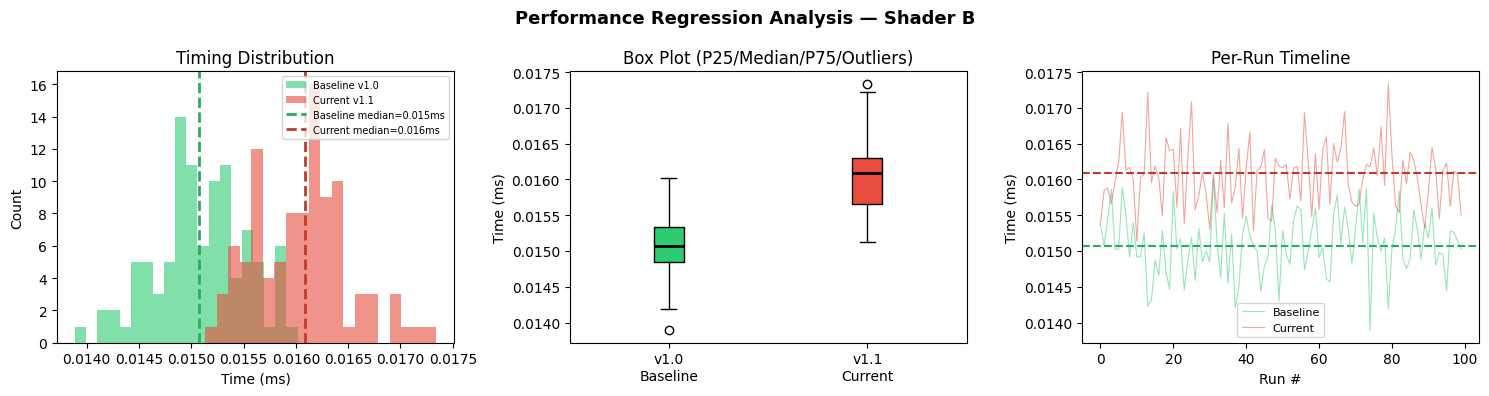

Summary: compiler v1.1 is 6.7% slower on Shader B — this would block the release.


In [11]:
# ── Visualize performance data like a real SDET dashboard ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Performance Regression Analysis — Shader B", fontsize=13, fontweight='bold')

# ── Left: distribution comparison ────────────────────────────────────────────
ax = axes[0]
ax.set_title("Timing Distribution")
ax.hist(baseline_result.times_ms,  bins=20, alpha=0.6, color='#2ecc71', label='Baseline v1.0')
ax.hist(regressed_result.times_ms, bins=20, alpha=0.6, color='#e74c3c', label='Current v1.1')
ax.axvline(baseline_result.median,  color='#27ae60', linestyle='--', lw=2, label=f'Baseline median={baseline_result.median:.3f}ms')
ax.axvline(regressed_result.median, color='#c0392b', linestyle='--', lw=2, label=f'Current median={regressed_result.median:.3f}ms')
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Count")
ax.legend(fontsize=7)

# ── Middle: box plot ──────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_title("Box Plot (P25/Median/P75/Outliers)")
bp = ax2.boxplot([baseline_result.times_ms, regressed_result.times_ms],
                  labels=['v1.0\nBaseline', 'v1.1\nCurrent'],
                  patch_artist=True,
                  medianprops=dict(color='black', lw=2))
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax2.set_ylabel("Time (ms)")

# ── Right: run-over-run timeline (trend) ──────────────────────────────────────
ax3 = axes[2]
ax3.set_title("Per-Run Timeline")
ax3.plot(baseline_result.times_ms,  alpha=0.5, color='#2ecc71', lw=0.8, label='Baseline')
ax3.plot(regressed_result.times_ms, alpha=0.5, color='#e74c3c', lw=0.8, label='Current')
ax3.axhline(baseline_result.median,  color='#27ae60', linestyle='--', lw=1.5)
ax3.axhline(regressed_result.median, color='#c0392b', linestyle='--', lw=1.5)
ax3.set_xlabel("Run #")
ax3.set_ylabel("Time (ms)")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

pct = (regressed_result.median - baseline_result.median) / baseline_result.median * 100
print(f"Summary: compiler v1.1 is {pct:.1f}% slower on Shader B — this would block the release.")

---
## 🎯 Challenge 2: Regression Detection

You are given performance data from four shaders across two compiler versions.
Your job is to identify which shaders have regressions, which have improvements,
and which are within noise.

**Requirements:**
- Use the `detect_regression()` function
- Report your findings as a summary table
- For any regression, state whether you would **block** the compiler release or not

**Threshold:** flag if median changes by more than 3%

### 🧠 Real SDET context
At NVIDIA, this analysis runs automatically after every compiler commit.
If a regression is detected, the SDET files a bug in JIRA, identifies the
commit that caused it (`git bisect`), and works with the compiler developer to fix it.

In [12]:
# ── Given data: performance measurements for 4 shaders, 2 compiler versions ──
np.random.seed(99)

shaders = {
    "Phong lighting"      : (2.10, 2.10 * 1.01),  # (baseline_mean, current_mean)
    "Shadow map lookup"   : (4.55, 4.55 * 1.12),  # ~12% slower
    "PBR material"        : (8.30, 8.30 * 0.91),  # ~9% faster (improvement)
    "Particle simulation" : (1.80, 1.80 * 1.008), # ~0.8% change (noise)
}

shader_data = {}
for name, (base_mean, curr_mean) in shaders.items():
    baseline_t = np.random.normal(base_mean, base_mean * 0.01, 80).tolist()
    current_t  = np.random.normal(curr_mean, curr_mean * 0.01, 80).tolist()
    shader_data[name] = (
        BenchmarkResult(f"{name} — v1.0", baseline_t),
        BenchmarkResult(f"{name} — v1.1", current_t),
    )

# ✏️ YOUR TASK:
# 1. Loop over shader_data
# 2. Call detect_regression(baseline, current, threshold_pct=3.0) for each
# 3. Print a final summary table showing which shaders regressed/improved/unchanged
# 4. State whether you would block the compiler v1.1 release and why

print("Analyzing compiler v1.0 → v1.1 performance changes:")
print("=" * 60)

# ✏️ YOUR CODE HERE


Analyzing compiler v1.0 → v1.1 performance changes:


---
## 🎯 Challenge 3: Performance Trend Analysis

A real SDET tracks performance over many compiler versions, not just two.
Your task is to analyze a multi-version performance history and:

1. Plot the performance trend over 20 compiler versions
2. Detect which version introduced the regression
3. Calculate a rolling baseline (average of last 5 stable versions)
4. Flag any version where performance exceeds baseline + 2 standard deviations

**This is exactly what NVIDIA's performance dashboard does automatically.**

### 🧠 Real SDET context: `git bisect`
Once you find *which version* caused the regression, you use `git bisect` to find
the exact commit:
```bash
git bisect start
git bisect bad v1.15     # current bad version
git bisect good v1.10    # last known good
# git checks out the midpoint — you run your benchmark and mark good/bad
# repeats until it isolates the exact commit
```

In [13]:
# ── Performance history across 20 compiler versions ───────────────────────────
np.random.seed(7)
n_versions = 20

# Versions 0-11: stable ~2.0 ms
# Version 12: regression introduced (+15%)
# Versions 13-19: remains regressed
version_medians = []
for v in range(n_versions):
    if v < 12:
        base = 2.0 + np.random.normal(0, 0.02)
    else:
        base = 2.3 + np.random.normal(0, 0.02)  # regressed
    version_medians.append(base)

version_labels = [f"v1.{v}" for v in range(n_versions)]

# ✏️ YOUR TASK:
# 1. Plot version_medians as a line chart with version_labels on x-axis
# 2. Compute a rolling baseline: for each version v, average the previous 5 versions
#    (for v < 5, use all available previous versions)
# 3. Plot the rolling baseline as a dashed line
# 4. Shade a "warning band" at baseline + 2*std of the stable period (v0-v11)
# 5. Mark the version(s) that exceed the warning band with a red dot
# 6. Print which version first exceeded the threshold

# ✏️ YOUR CODE HERE


---
## ✅ Module Summary

| Skill | What you learned | Job relevance |
|---|---|---|
| **Graphics pipeline** | Vertex/pixel shaders, compiler stages | You need to know *what* you're testing |
| **Test planning** | Categories, edge cases, regression suites | Core SDET deliverable |
| **Test automation** | TestCase/TestPlan framework, AAA pattern | "Automate tests with NVIDIA test frameworks" |
| **GPU benchmarking** | CUDA events, warmup, distributions | "Performance testing" |
| **Statistical analysis** | Z-score, t-test, percentiles | "Generate statistics, identify outliers" |
| **Regression detection** | Threshold + significance testing | "Identify regression root causes" |
| **Trend analysis** | Rolling baseline, change-point detection | "Maintain historical data and baselines" |

---

### 🔜 Next steps for this role
- **DirectX / Vulkan APIs** — learn how shaders are submitted to the GPU
- **HLSL / GLSL** — write actual shader code to understand what the compiler handles
- **Compiler internals** — understand IR, optimization passes, register allocation
- **Profiling tools** — NVIDIA Nsight Graphics, RenderDoc for visual debugging
- **CI/CD pipelines** — how automated test runs are triggered on compiler commits

### 📖 Resources
- [HLSL Reference (Microsoft)](https://learn.microsoft.com/en-us/windows/win32/direct3dhlsl/dx-graphics-hlsl-reference)
- [Vulkan Tutorial](https://vulkan-tutorial.com/)
- [NVIDIA Nsight Graphics](https://developer.nvidia.com/nsight-graphics)
- [Python unittest docs](https://docs.python.org/3/library/unittest.html)
- [SciPy stats for performance analysis](https://docs.scipy.org/doc/scipy/reference/stats.html)